# Jupyter shortcuts
up / down arrows: Navigate up and down \
a / b: Create a cell above (a) or below (b) the current cell\
m / y: Change the cell type to Markdown (m) or code (y)\
Shift+up or Shift+down: Select multiple cells\
Shift+m: Merge cells

In [1]:
import sys
print(sys.executable)
print(sys.version)

d:\Programs\Projects\Analysis - European Cost of living\.venv\Scripts\python.exe
3.10.6 (tags/v3.10.6:9c7b4bd, Aug  1 2022, 21:53:49) [MSC v.1932 64 bit (AMD64)]


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Everything works!")
print("Environment ready!")
print("pandas:", pd.__version__)
print("numpy:", np.__version__)

Everything works!
Environment ready!
pandas: 2.3.3
numpy: 2.2.6


# Loading raw data PLI

In [3]:
from pathlib import Path

raw_dir = Path("../data/raw") #../ is to go back a level out of the notebooks directory

for file in raw_dir.iterdir(): #raw_dir.iterdir() lists the files inside that directory
    print(file.name, "-", file.stat().st_size, "bytes") 

earn_nt_net_earnings_euro.csv - 5881 bytes
earn_nt_net__earnings_50.csv - 5817 bytes
eurostat_prc_ppp_ind_1_2025_pli_e011.csv - 9879 bytes


In [4]:
file_path = raw_dir / "eurostat_prc_ppp_ind_1_2025_pli_e011.csv"
#with .. as file is a better syntax; Python handers the closing of the file automatically
with open(file_path, "r", encoding="utf-8") as file: #r is for read the file; Encoding utf-8 is a very common encoding that contain country specific characters
    for _ in range(10): #we use _ not i because we don't need the numbers stored; we just need the action to be repeated
        print(file.readline().rstrip()) #file.readline().rstrip() two operations chained together, one reads the line and the other removes the newline character at the right / end of the line \n

STRUCTURE,STRUCTURE_ID,STRUCTURE_NAME,freq,Time frequency,indic_ppp,Purchasing power parities indicator,ppp_cat18,Analytical categories for purchasing power parities (PPPs) calculation (based on COICOP18),geo,Geopolitical entity (reporting),TIME_PERIOD,Time,OBS_VALUE,Observation value,OBS_FLAG,Observation status (Flag) V2 structure,CONF_STATUS,Confidentiality status (flag)
dataflow,ESTAT:PRC_PPP_IND_1(1.0),"Purchasing power parities, price level indices, nominal and real expenditures by analytical categories - based on COICOP 2018",A,Annual,PLI_EU27_2020,Price level indices (EU27_2020=100),E011,Household final consumption expenditure,AT,Austria,2025,,113.0,,,,,
dataflow,ESTAT:PRC_PPP_IND_1(1.0),"Purchasing power parities, price level indices, nominal and real expenditures by analytical categories - based on COICOP 2018",A,Annual,PLI_EU27_2020,Price level indices (EU27_2020=100),E011,Household final consumption expenditure,BE,Belgium,2025,,116.2,,,,,
dataflow,ESTAT:PRC_PPP_IND_1(1.0),"P

In [5]:
df = pd.read_csv(file_path)

In [6]:
df.shape

(32, 19)

In [7]:
df.head()

,STRUCTURE,STRUCTURE_ID,STRUCTURE_NAME,freq,Time frequency,indic_ppp,Purchasing power parities indicator,ppp_cat18,Analytical categories for purchasing power parities (PPPs) calculation (based on COICOP18),geo,Geopolitical entity (reporting),TIME_PERIOD,Time,OBS_VALUE,Observation value,OBS_FLAG,Observation status (Flag) V2 structure,CONF_STATUS,Confidentiality status (flag)
0,dataflow,ESTAT:PRC_PPP_IND_1(1.0),"Purchasing power parities, price level indices...",A,Annual,PLI_EU27_2020,Price level indices (EU27_2020=100),E011,Household final consumption expenditure,AT,Austria,2025,NaN,113.0,NaN,NaN,NaN,NaN,NaN
1,dataflow,ESTAT:PRC_PPP_IND_1(1.0),"Purchasing power parities, price level indices...",A,Annual,PLI_EU27_2020,Price level indices (EU27_2020=100),E011,Household final consumption expenditure,BE,Belgium,2025,NaN,116.2,NaN,NaN,NaN,NaN,NaN
2,dataflow,ESTAT:PRC_PPP_IND_1(1.0),"Purchasing power parities, price level indices...",A,Annual,PLI_EU27_2020,Price level indices (EU27_2020=100),E011,Household final consumption expenditure,BG,Bulgaria,2025,NaN,62.5,NaN,NaN,NaN,NaN,NaN
3,dataflow,ESTAT:PRC_PPP_IND_1(1.0),"Purchasing power parities, price level indices...",A,Annual,PLI_EU27_2020,Price level indices (EU27_2020=100),E011,Household final consumption expenditure,CH,Switzerland,2025,NaN,171.3,NaN,NaN,NaN,NaN,NaN
4,dataflow,ESTAT:PRC_PPP_IND_1(1.0),"Purchasing power parities, price level indices...",A,Annual,PLI_EU27_2020,Price level indices (EU27_2020=100),E011,Household final consumption expenditure,CY,Cyprus,2025,NaN,89.2,NaN,NaN,NaN,NaN,NaN


In [8]:
df.dtypes

STRUCTURE                                                                                      object
STRUCTURE_ID                                                                                   object
STRUCTURE_NAME                                                                                 object
freq                                                                                           object
Time frequency                                                                                 object
indic_ppp                                                                                      object
Purchasing power parities indicator                                                            object
ppp_cat18                                                                                      object
Analytical categories for purchasing power parities (PPPs) calculation (based on COICOP18)     object
geo                                                                               

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32 entries, 0 to 31
Data columns (total 19 columns):
 #   Column                                                                                      Non-Null Count  Dtype  
---  ------                                                                                      --------------  -----  
 0   STRUCTURE                                                                                   32 non-null     object 
 1   STRUCTURE_ID                                                                                32 non-null     object 
 2   STRUCTURE_NAME                                                                              32 non-null     object 
 3   freq                                                                                        32 non-null     object 
 4   Time frequency                                                                              32 non-null     object 
 5   indic_ppp                                    

In [10]:
df[["geo","Geopolitical entity (reporting)"]]

,geo,Geopolitical entity (reporting)
0,AT,Austria
1,BE,Belgium
2,BG,Bulgaria
3,CH,Switzerland
4,CY,Cyprus
5,CZ,Czechia
6,DE,Germany
7,DK,Denmark
8,EA21,Euro area – 21 countries (from 2026)
9,EE,Estonia


In [11]:
df[["geo", "Geopolitical entity (reporting)", "OBS_VALUE"]]

,geo,Geopolitical entity (reporting),OBS_VALUE
0,AT,Austria,113.0
1,BE,Belgium,116.2
2,BG,Bulgaria,62.5
3,CH,Switzerland,171.3
4,CY,Cyprus,89.2
5,CZ,Czechia,89.4
6,DE,Germany,108.3
7,DK,Denmark,139.7
8,EA21,Euro area – 21 countries (from 2026),103.4
9,EE,Estonia,101.2


In [12]:
df_analysis = df.drop(
    df[df["geo"].isin(["CH","IS","NO","EA21"])].index
)

In [13]:
df_analysis.shape

(28, 19)

In [14]:
df_analysis["geo"].tolist()

['AT',
 'BE',
 'BG',
 'CY',
 'CZ',
 'DE',
 'DK',
 'EE',
 'EL',
 'ES',
 'EU27_2020',
 'FI',
 'FR',
 'HR',
 'HU',
 'IE',
 'IT',
 'LT',
 'LU',
 'LV',
 'MT',
 'NL',
 'PL',
 'PT',
 'RO',
 'SE',
 'SI',
 'SK']

# Data Validation / Quality Check PLI

In [15]:
#Duplicates
df_analysis["geo"].duplicated().sum()

np.int64(0)

In [16]:
#Check for missing PLI values
df_analysis["OBS_VALUE"].isna().sum()

np.int64(0)

#Check the year / indicator / expenditure category

In [17]:
df_analysis["TIME_PERIOD"].unique()

array([2025])

In [18]:
df_analysis["indic_ppp"].unique()

array(['PLI_EU27_2020'], dtype=object)

In [19]:
df_analysis["ppp_cat18"].unique()

array(['E011'], dtype=object)

# Descriptive statistics PLI

In [20]:
df_countries = df_analysis[
    df_analysis["geo"] != "EU27_2020"
]

In [21]:
df_countries.shape

(27, 19)

In [22]:
df_countries["OBS_VALUE"].describe()

count     27.000000
mean      97.937037
std       20.959854
min       62.500000
25%       84.200000
50%       91.600000
75%      114.300000
max      139.700000
Name: OBS_VALUE, dtype: float64

In [23]:
df_analysis["OBS_VALUE"].describe() # with the aggregate the results are a bit of track

count     28.000000
mean      98.010714
std       20.571741
min       62.500000
25%       84.700000
50%       91.750000
75%      113.650000
max      139.700000
Name: OBS_VALUE, dtype: float64

# Bar chart

In [24]:
#Sorting data
df_countries_sorted = df_countries.sort_values(
    "OBS_VALUE",
    ascending=True
)

In [25]:
df_countries_sorted[
    ["Geopolitical entity (reporting)", "OBS_VALUE"]
]

,Geopolitical entity (reporting),OBS_VALUE
2,Bulgaria,62.5
28,Romania,65.1
26,Poland,73.3
16,Hungary,77.5
15,Croatia,78.4
20,Lithuania,82.8
22,Latvia,83.2
31,Slovakia,85.2
27,Portugal,86.6
10,Greece,87.4


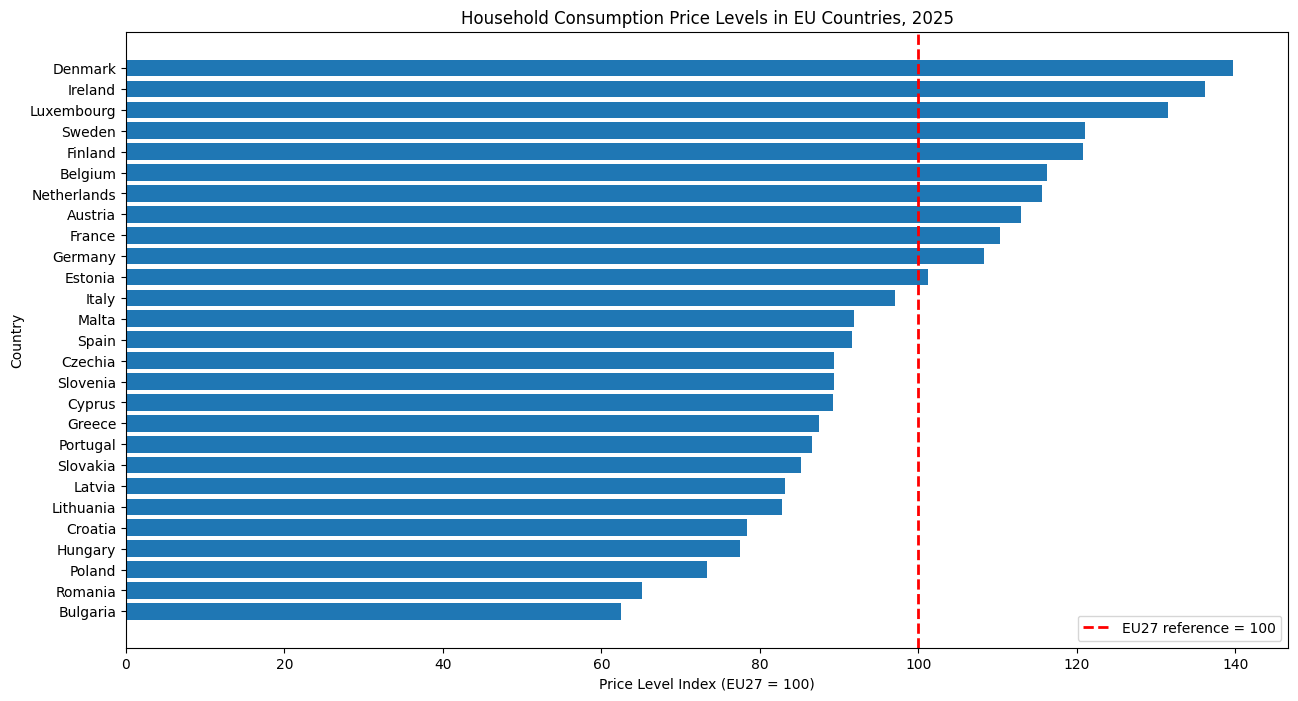

In [26]:
fig, ax = plt.subplots(figsize=(15, 8))

ax.barh(
    df_countries_sorted["Geopolitical entity (reporting)"],
    df_countries_sorted["OBS_VALUE"]
)

#Adding the values at the end of the bars
# for bar in ax.patches:
#     value = bar.get_width()
    
#     ax.text(
#         value + 1,
#         bar.get_y() + bar.get_height() / 2,
#         f"{value:.1f}",
#         va="center"
#     )

#Adding the reference line at 100
ax.axvline(
    100,
    color = "red",
    linestyle="--",
    linewidth=2,
    label="EU27 reference = 100"
)

ax.set_xlabel("Price Level Index (EU27 = 100)")
ax.set_ylabel("Country")
ax.set_title("Household Consumption Price Levels in EU Countries, 2025")

ax.legend()

plt.show()

# Analytics

In [27]:
# the percentage by which the highest-PLI country exceeds the lowest-PLI country, using the lowest-priced country as the base
(
    df_countries["OBS_VALUE"].max()
    - df_countries["OBS_VALUE"].min()
) / df_countries["OBS_VALUE"].min() * 100

np.float64(123.51999999999998)

In [28]:
# the percentage by which the lowest-PLI country is below the highest-PLI country, using the highest-priced country as the base
(
    df_countries["OBS_VALUE"].max()
    - df_countries["OBS_VALUE"].min()
) / df_countries["OBS_VALUE"].max() * 100

np.float64(55.26127415891195)

In [29]:
min_pli = df_countries["OBS_VALUE"].min()
max_pli = df_countries["OBS_VALUE"].max()

print(f"Minimum PLI: {min_pli:.1f}")
print(f"Maximum PLI: {max_pli:.1f}")

Minimum PLI: 62.5
Maximum PLI: 139.7


In [30]:
lowest_country = df_countries.loc[
    df_countries["OBS_VALUE"].idxmin(),
    "Geopolitical entity (reporting)"
]

highest_country = df_countries.loc[
    df_countries["OBS_VALUE"].idxmax(),
    "Geopolitical entity (reporting)"
]

print(f"Lowest PLI: {lowest_country} ({min_pli:.1f})")
print(f"Highest PLI: {highest_country} ({max_pli:.1f})")

Lowest PLI: Bulgaria (62.5)
Highest PLI: Denmark (139.7)


# Conclusions

Our 2025 PLI dataset has:

27 EU countries\
EU27 reference retained separately\
no duplicate country observations\
no missing PLI values\
consistent year: 2025\
consistent indicator: PLI_EU27_2020\
consistent category: E011\
Bulgaria: 62.5\
Denmark: 139.7\
unweighted country mean: 97.94\
median: 91.6\

# Loading raw data income

In [31]:
from pathlib import Path

raw_data_path2 = Path("../data/raw")

for file in raw_data_path2.iterdir():
    print(file.name, "-", file.stat().st_size, "bytes")

earn_nt_net_earnings_euro.csv - 5881 bytes
earn_nt_net__earnings_50.csv - 5817 bytes
eurostat_prc_ppp_ind_1_2025_pli_e011.csv - 9879 bytes


In [32]:
file_path2 = raw_data_path2 / "earn_nt_net_earnings_euro.csv"

with open(file_path2, "r", encoding="utf-8") as file:
    for _ in range(10):
        print(file.readline().rstrip())

STRUCTURE,STRUCTURE_ID,STRUCTURE_NAME,freq,Time frequency,currency,Currency,estruct,Earnings structure,ecase,Earnings case,geo,Geopolitical entity (reporting),TIME_PERIOD,Time,OBS_VALUE,Observation value,OBS_FLAG,Observation status (Flag) V2 structure,CONF_STATUS,Confidentiality status (flag)
dataflow,ESTAT:EARN_NT_NET(1.0),Annual net earnings,A,Annual,EUR,Euro,NET,Net earning,P1_NCH_AW100,Single person without children earning 100% of the average earning,AT,Austria,2025,,36797.90,,,,,
dataflow,ESTAT:EARN_NT_NET(1.0),Annual net earnings,A,Annual,EUR,Euro,NET,Net earning,P1_NCH_AW100,Single person without children earning 100% of the average earning,BE,Belgium,2025,,34642.30,,,,,
dataflow,ESTAT:EARN_NT_NET(1.0),Annual net earnings,A,Annual,EUR,Euro,NET,Net earning,P1_NCH_AW100,Single person without children earning 100% of the average earning,BG,Bulgaria,2025,,13016.65,,,,,
dataflow,ESTAT:EARN_NT_NET(1.0),Annual net earnings,A,Annual,EUR,Euro,NET,Net earning,P1_NCH_AW100,Single person w

In [33]:
df_earnings = pd.read_csv(file_path2)

In [34]:
df_earnings.shape

(28, 21)

In [35]:
df_earnings.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28 entries, 0 to 27
Data columns (total 21 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   STRUCTURE                               28 non-null     object 
 1   STRUCTURE_ID                            28 non-null     object 
 2   STRUCTURE_NAME                          28 non-null     object 
 3   freq                                    28 non-null     object 
 4   Time frequency                          28 non-null     object 
 5   currency                                28 non-null     object 
 6   Currency                                28 non-null     object 
 7   estruct                                 28 non-null     object 
 8   Earnings structure                      28 non-null     object 
 9   ecase                                   28 non-null     object 
 10  Earnings case                           28 non-null     object 


In [36]:
df_earnings[["geo", "Geopolitical entity (reporting)", "OBS_VALUE"]]

,geo,Geopolitical entity (reporting),OBS_VALUE
0,AT,Austria,36797.90
1,BE,Belgium,34642.30
2,BG,Bulgaria,13016.65
3,CY,Cyprus,23524.01
4,CZ,Czechia,19568.67
5,DE,Germany,31000.48
6,DK,Denmark,41981.24
7,EE,Estonia,20044.71
8,EL,Greece,15049.76
9,ES,Spain,25262.74


EU mean is 26928.97

# Data Validation / Quality Check income

In [37]:
df_earnings.columns.tolist()

['STRUCTURE',
 'STRUCTURE_ID',
 'STRUCTURE_NAME',
 'freq',
 'Time frequency',
 'currency',
 'Currency',
 'estruct',
 'Earnings structure',
 'ecase',
 'Earnings case',
 'geo',
 'Geopolitical entity (reporting)',
 'TIME_PERIOD',
 'Time',
 'OBS_VALUE',
 'Observation value',
 'OBS_FLAG',
 'Observation status (Flag) V2 structure',
 'CONF_STATUS',
 'Confidentiality status (flag)']

In [38]:
#Duplicates
df_earnings["geo"].duplicated().sum()

np.int64(0)

In [39]:
#Check for missing PLI values
df_earnings["OBS_VALUE"].isna().sum()

np.int64(0)

In [40]:
df_earnings["TIME_PERIOD"].unique()

array([2025])

In [41]:
df_earnings["Earnings structure"].unique()

array(['Net earning'], dtype=object)

In [42]:
df_earnings["Earnings case"].unique()

array(['Single person without children earning 100% of the average earning'],
      dtype=object)

In [43]:
df_earnings["currency"].unique()

array(['EUR'], dtype=object)

# Descriptive statistics income

In [44]:
df_earnings["OBS_VALUE"].describe()

count       28.000000
mean     25866.062500
std      10601.669596
min      12967.220000
25%      17140.220000
50%      23997.640000
75%      33886.872500
max      54259.930000
Name: OBS_VALUE, dtype: float64

In [45]:
df_earnings_countries = df_earnings[
    df_earnings["geo"] != "EU27_2020"
]

In [46]:
df_earnings_countries["OBS_VALUE"].describe()

count       27.000000
mean     25826.695556
std      10801.538594
min      12967.220000
25%      17024.370000
50%      23524.010000
75%      34132.705000
max      54259.930000
Name: OBS_VALUE, dtype: float64

In [47]:
comparison = pd.DataFrame({
    "PLI": df_countries["OBS_VALUE"],
    "Net earnings EUR": df_earnings_countries["OBS_VALUE"]
})

comparison.describe()

,PLI,Net earnings EUR
count,27.000000,27.000000
mean,97.937037,25826.695556
std,20.959854,10801.538594
min,62.500000,12967.220000
25%,84.200000,17024.370000
50%,91.600000,23524.010000
75%,114.300000,34132.705000
max,139.700000,54259.930000


In [48]:
set(df_countries["geo"]) == set(df_earnings_countries["geo"])

True

In [49]:
pli = df_countries[
    ["geo", "Geopolitical entity (reporting)", "OBS_VALUE"]
].rename(
    columns={"OBS_VALUE": "pli"}
)

earnings = df_earnings_countries[
    ["geo", "OBS_VALUE"]
].rename(
    columns={"OBS_VALUE": "net_earnings_eur"}
)

In [50]:
df_combined = pli.merge(
    earnings,
    on="geo",
    how="inner"
)

# inner → observations present in both datasets
# left → keep everything from the left dataset
# right → keep everything from the right dataset
# outer → keep everything from both

In [51]:
df_combined.shape

(27, 4)

In [52]:
df_combined.head()

,geo,Geopolitical entity (reporting),pli,net_earnings_eur
0,AT,Austria,113.0,36797.90
1,BE,Belgium,116.2,34642.30
2,BG,Bulgaria,62.5,13016.65
3,CY,Cyprus,89.2,23524.01
4,CZ,Czechia,89.4,19568.67


# Plots and Stats
Are countries with higher net earnings also countries with higher price levels?

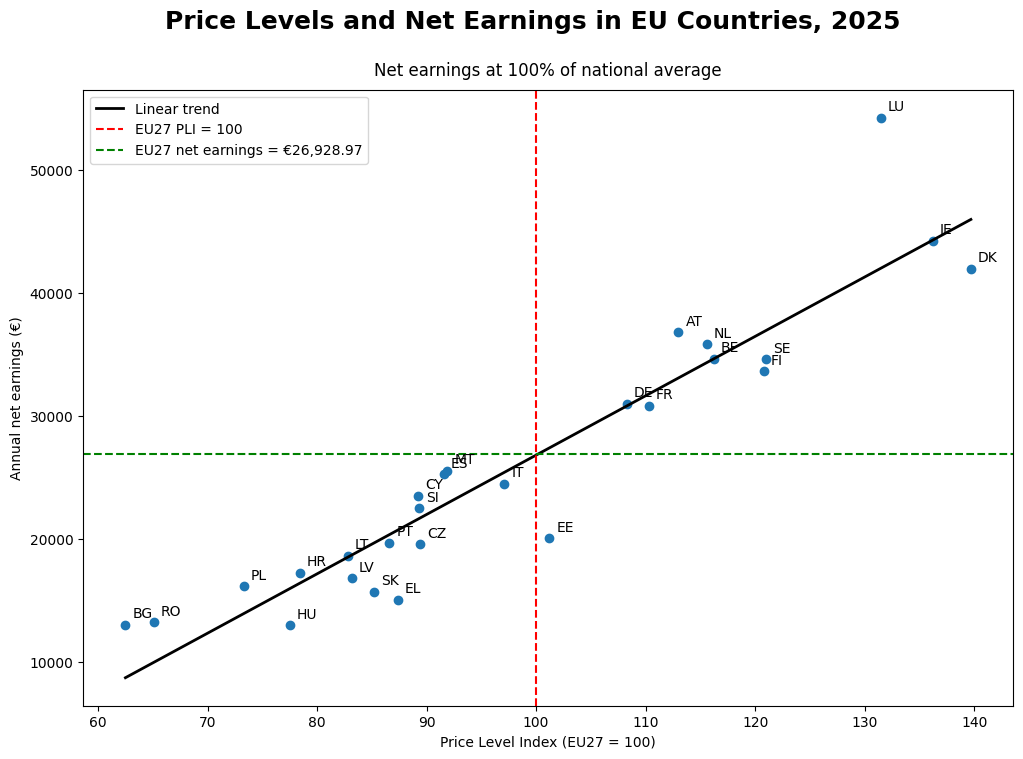

In [53]:
fig, ax = plt.subplots(figsize=(12, 8))

fig.suptitle(
    "Price Levels and Net Earnings in EU Countries, 2025",
    fontsize=18,
    fontweight="bold"
)

ax.set_title(
    "Net earnings at 100% of national average",
    fontsize=12,
    pad=10
)

x = df_combined["pli"]
y = df_combined["net_earnings_eur"]

ax.scatter(x,y)

for _, row in df_combined.iterrows():
    ax.annotate(
        row["geo"],
        (row["pli"], row["net_earnings_eur"]),
        xytext=(5, 5),
        textcoords="offset points"
    )


# Linear regression line
slope, intercept = np.polyfit(x, y, 1)

x_line = np.linspace(x.min(), x.max(), 100)
y_line = slope * x_line + intercept

ax.plot(
    x_line,
    y_line,
    color="black",
    linestyle="-",
    linewidth=2,
    label="Linear trend"
)

# EU27 reference lines
ax.axvline(
    x=100,
    color="red",
    linestyle="--",
    linewidth=1.5,
    label="EU27 PLI = 100"
)

ax.axhline(
    y=df_earnings.loc[df_earnings["geo"] == "EU27_2020", "OBS_VALUE"].iloc[0],
    color="green",
    linestyle="--",
    linewidth=1.5,
    label=f"EU27 net earnings = €{df_earnings.loc[df_earnings['geo'] == 'EU27_2020', 'OBS_VALUE'].iloc[0]:,.2f}"
)

ax.set_xlabel("Price Level Index (EU27 = 100)")
ax.set_ylabel("Annual net earnings (€)")


ax.legend()

plt.show()

In [54]:
# Pearson correlation coefficient
correlation = df_combined["pli"].corr(
    df_combined["net_earnings_eur"]
)

r_squared = correlation ** 2


print(f"Pearson correlation: {correlation:.3f}")
print(f"R²: {r_squared:.3f}")

Pearson correlation: 0.937
R²: 0.877


In [55]:
#Residual regression approach for caputuring the observations on Hungary and Luxemburg

# Calculating expecting earnings

slope, intercept = np.polyfit(x,y,1)
print(slope,intercept)

482.7439685955376 -21451.81837619183


In [56]:
df_combined["predicted_earnings"] = (intercept + slope * df_combined["pli"])
print("Predicted earnings = ",intercept," + ", slope,"* PLI")

Predicted earnings =  -21451.81837619183  +  482.7439685955376 * PLI


In [57]:
df_combined["earnings_residual"] = (
    df_combined["net_earnings_eur"]
    - df_combined["predicted_earnings"]
)
print("Earnings residuals(i) = Net earnings(i) - Predicted earnings(i)")

Earnings residuals(i) = Net earnings(i) - Predicted earnings(i)


In [58]:
df_residuals = df_combined.sort_values(
    "earnings_residual",
    ascending=False
)

In [59]:
df_residuals[
    [
        "geo",
        "pli",
        "net_earnings_eur",
        "predicted_earnings",
        "earnings_residual"
    ]
]

,geo,pli,net_earnings_eur,predicted_earnings,earnings_residual
17,LU,131.5,54259.93,42029.013494,12230.916506
2,BG,62.5,13016.65,8719.679661,4296.970339
0,AT,113.0,36797.90,33098.250075,3699.649925
23,RO,65.1,13232.74,9974.813979,3257.926021
19,MT,91.9,25543.95,22912.352338,2631.597662
9,ES,91.6,25262.74,22767.529147,2495.210853
21,PL,73.3,16163.12,13933.314522,2229.805478
3,CY,89.2,23524.01,21608.943623,1915.066377
20,NL,115.6,35836.93,34353.384393,1483.545607
12,HR,78.4,17256.07,16395.308762,860.761238


In [60]:
df_combined.info(
)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27 entries, 0 to 26
Data columns (total 6 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   geo                              27 non-null     object 
 1   Geopolitical entity (reporting)  27 non-null     object 
 2   pli                              27 non-null     float64
 3   net_earnings_eur                 27 non-null     float64
 4   predicted_earnings               27 non-null     float64
 5   earnings_residual                27 non-null     float64
dtypes: float64(4), object(2)
memory usage: 1.4+ KB


In [61]:
eu27_earnings = df_earnings.loc[df_earnings["geo"] == "EU27_2020", "OBS_VALUE"].iloc[0]

In [62]:
df_combined["earnings_index"] = (
    df_combined["net_earnings_eur"]
    / eu27_earnings
) * 100

In [63]:
df_combined["earnings_to_pli"] = (
    df_combined["net_earnings_eur"]
    / df_combined["pli"]
)

In [64]:
df_affordability = df_combined.sort_values(
    "earnings_to_pli",
    ascending=False
)

df_affordability[
    [
        "geo",
        "pli",
        "net_earnings_eur",
        "earnings_to_pli"
    ]
]

,geo,pli,net_earnings_eur,earnings_to_pli
17,LU,131.5,54259.93,412.623042
0,AT,113.0,36797.90,325.645133
14,IE,136.2,44263.30,324.987518
20,NL,115.6,35836.93,310.008045
6,DK,139.7,41981.24,300.509950
1,BE,116.2,34642.30,298.126506
5,DE,108.3,31000.48,286.246353
24,SE,121.0,34624.37,286.151818
11,FR,110.3,30831.60,279.524932
10,FI,120.8,33641.04,278.485430


In [65]:
eu27_earnings = df_earnings.loc[
    df_earnings["geo"] == "EU27_2020",
    "OBS_VALUE"
].iloc[0]
print(eu27_earnings)

26928.97


In [66]:
df_combined["affordability_index"] = (
    (df_combined["earnings_to_pli"])
    / (eu27_earnings / 100)
) * 100

In [67]:
df_affordability = df_combined.sort_values(
    "affordability_index",
    ascending=True
)

df_affordability[
    [
        "geo",
        "pli",
        "net_earnings_eur",
        "earnings_to_pli",
        "affordability_index"
    ]
]

,geo,pli,net_earnings_eur,earnings_to_pli,affordability_index
13,HU,77.5,12967.22,167.318968,62.133445
8,EL,87.4,15049.76,172.194050,63.943794
26,SK,85.2,15685.92,184.107042,68.367651
7,EE,101.2,20044.71,198.070257,73.552853
18,LV,83.2,16792.67,201.834976,74.950871
23,RO,65.1,13232.74,203.267896,75.482982
2,BG,62.5,13016.65,208.266400,77.339163
4,CZ,89.4,19568.67,218.888926,81.283809
12,HR,78.4,17256.07,220.102934,81.734628
21,PL,73.3,16163.12,220.506412,81.884458


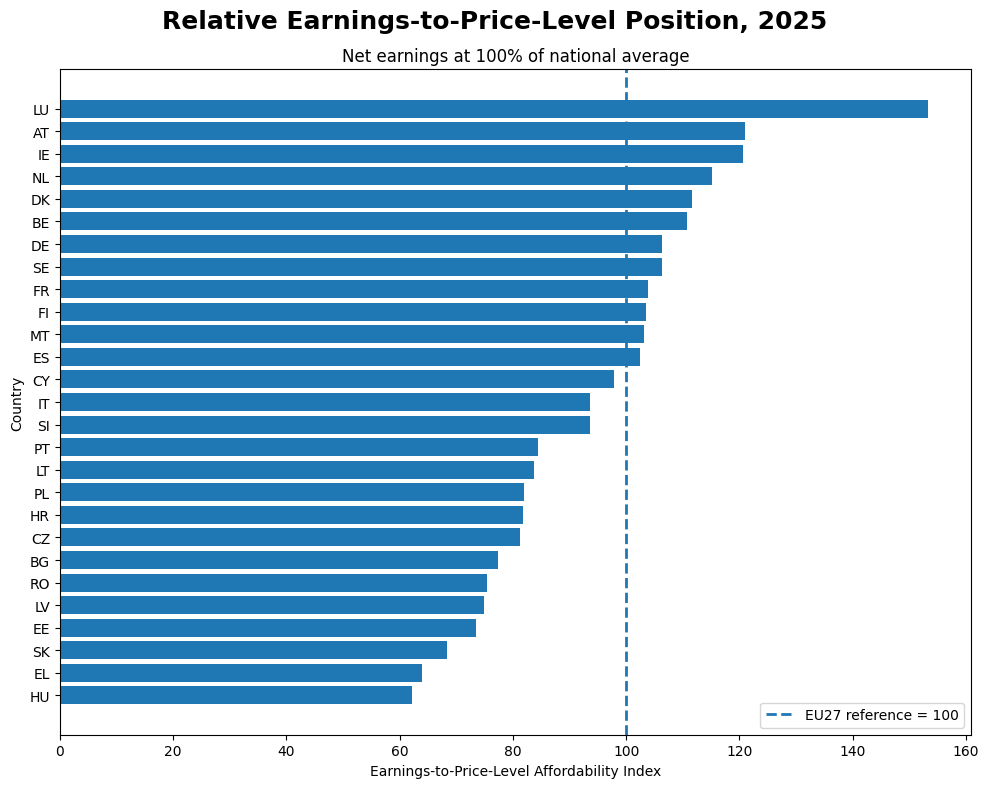

In [68]:
fig, ax = plt.subplots(figsize=(10, 8))

fig.suptitle(
    "Relative Earnings-to-Price-Level Position, 2025",
    fontsize=18,
    fontweight="bold"
)

# ax.set_title(
#     "Net earnings at 100% of national average",
#     fontsize=12,
#     pad=10
# )

ax.barh(
    df_affordability["geo"],
    df_affordability["affordability_index"]
)

ax.axvline(
    100,
    linestyle="--",
    linewidth=2,
    label="EU27 reference = 100"
)

ax.set_xlabel("Earnings-to-Price-Level Affordability Index")
ax.set_ylabel("Country")
ax.set_title(
    "Net earnings at 100% of national average"
)

ax.legend()

plt.tight_layout()
plt.show()

In [69]:
# Normalize variables
# calculate each country's earnings and price level relative to the EU27
# price_level_index is simply the PLI because the PLI is already expressed with EU27 = 100

df_combined["earnings_index"] = (
    df_combined["net_earnings_eur"]
    / eu27_earnings
) * 100

df_combined["price_level_index"] = df_combined["pli"]

In [70]:
df_combined[
    [
        "geo",
        "earnings_index",
        "price_level_index",
        "affordability_index"
    ]
].sort_values(
    "affordability_index",
    ascending=False
)

,geo,earnings_index,price_level_index,affordability_index
17,LU,201.492779,131.5,153.226448
0,AT,136.648004,113.0,120.927437
14,IE,164.370564,136.2,120.683234
20,NL,133.079468,115.6,115.120647
6,DK,155.896197,139.7,111.593555
1,BE,128.643242,116.2,110.708470
5,DE,115.119442,108.3,106.296807
24,SE,128.576659,121.0,106.261702
11,FR,114.492311,110.3,103.800826
10,FI,124.925090,120.8,103.414810


# 50% Analysis

Loading data

In [71]:
df_earnings_50 = pd.read_csv(r"D:\Programs\Projects\Analysis - European Cost of living\data\raw\earn_nt_net__earnings_50.csv")

In [72]:
df_earnings_50.shape

(28, 21)

In [73]:
df_earnings_50.info(

)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28 entries, 0 to 27
Data columns (total 21 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   STRUCTURE                               28 non-null     object 
 1   STRUCTURE_ID                            28 non-null     object 
 2   STRUCTURE_NAME                          28 non-null     object 
 3   freq                                    28 non-null     object 
 4   Time frequency                          28 non-null     object 
 5   currency                                28 non-null     object 
 6   Currency                                28 non-null     object 
 7   estruct                                 28 non-null     object 
 8   Earnings structure                      28 non-null     object 
 9   ecase                                   28 non-null     object 
 10  Earnings case                           28 non-null     object 


# Descriptive statistics

In [74]:
df_earnings_50["OBS_VALUE"].describe()

count       28.000000
mean     15922.270714
std       7746.099165
min       6483.610000
25%       9549.527500
50%      14252.450000
75%      19814.222500
max      36112.840000
Name: OBS_VALUE, dtype: float64

In [75]:
eu27_50 = df_earnings_50.loc[
    df_earnings_50["geo"] == "EU27_2020",
    "OBS_VALUE"
].iloc[0]

In [76]:
print(eu27_50)

16722.37


In [77]:
df_earnings_50 = df_earnings_50[
    ~df_earnings_50["geo"].isin(["EU27_2020"])
]

In [78]:
df_earnings_50.shape

(27, 21)

In [79]:
df_earnings_50[["geo", "Geopolitical entity (reporting)", "OBS_VALUE"]].sort_values("OBS_VALUE")

,geo,Geopolitical entity (reporting),OBS_VALUE
14,HU,Hungary,6483.61
2,BG,Bulgaria,6508.32
24,RO,Romania,6741.43
27,SK,Slovakia,8389.57
8,EL,Greece,8650.50
19,LV,Latvia,9176.64
22,PL,Poland,9370.90
13,HR,Croatia,9609.07
17,LT,Lithuania,10771.32
7,EE,Estonia,11748.91


Creating a new dataFrame with the data from the previous analysis

In [80]:
df_combined.columns

Index(['geo', 'Geopolitical entity (reporting)', 'pli', 'net_earnings_eur',
       'predicted_earnings', 'earnings_residual', 'earnings_index',
       'earnings_to_pli', 'affordability_index', 'price_level_index'],
      dtype='object')

In [81]:
(df_combined["pli"] == df_combined["price_level_index"]).all()

np.True_

In [82]:
df_combined = df_combined.drop(columns=["price_level_index"])

In [83]:
df_50 = df_earnings_50[["geo", "OBS_VALUE"]].copy()

df_50 = df_50.rename(columns={
    "OBS_VALUE": "net_earnings_50_eur"
})

In [84]:
df_combined_50 = df_combined[["geo", "pli"]].merge(
    df_50,
    on="geo",
    how="inner"
)

In [85]:
df_combined_50.columns

Index(['geo', 'pli', 'net_earnings_50_eur'], dtype='object')

# Plot earnings to pli at 50% of average earnings

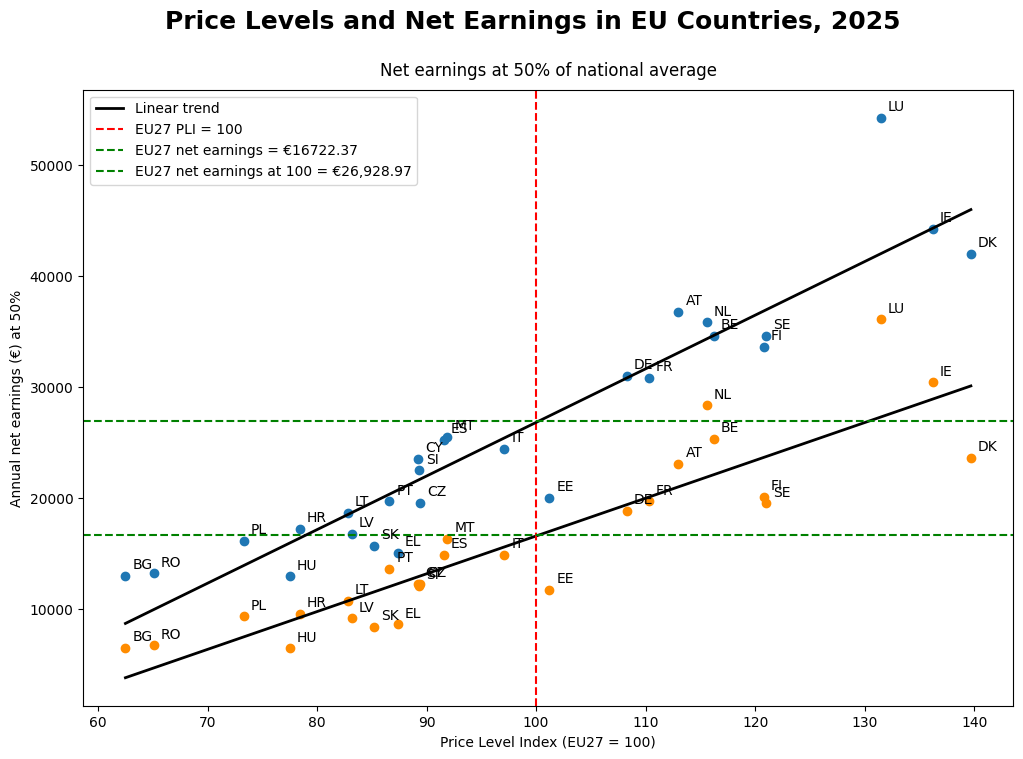

In [ ]:
fig, ax = plt.subplots(figsize=(12, 8))

fig.suptitle(
    "Price Levels and Net Earnings in EU Countries, 2025",
    fontsize=18,
    fontweight="bold"
)

ax.set_title(
    "Net earnings at 50% of national average",
    fontsize=12,
    pad=10
)

x = df_combined_50["pli"]
y = df_combined_50["net_earnings_50_eur"]

ax.scatter(x,y,color="darkorange")


for _, row in df_combined_50.iterrows():
    ax.annotate(
        row["geo"],
        (row["pli"], row["net_earnings_50_eur"]),
        xytext=(5, 5),
        textcoords="offset points"
    )


# Linear regression line
slope, intercept = np.polyfit(x, y, 1)

x_line = np.linspace(x.min(), x.max(), 100)
y_line = slope * x_line + intercept

ax.plot(
    x_line,
    y_line,
    color="black",
    linestyle="-",
    linewidth=2,
    label="Linear trend"
)

# EU27 reference lines
ax.axvline(
    x=100,
    color="red",
    linestyle="--",
    linewidth=1.5,
    label="EU27 PLI = 100"
)

ax.axhline(
    y=eu27_50,
    color="green",
    linestyle="--",
    linewidth=1.5,
    label=f"EU27 net earnings = €{eu27_50}"
)

ax.set_xlabel("Price Level Index (EU27 = 100)")
ax.set_ylabel("Annual net earnings (€) at 50%")


# ## Inresting plot
# x1 = df_combined["pli"]
# y1 = df_combined["net_earnings_eur"]

# ax.scatter(x1,y1)

# for _, row in df_combined.iterrows():
#     ax.annotate(
#         row["geo"],
#         (row["pli"], row["net_earnings_eur"]),
#         xytext=(5, 5),
#         textcoords="offset points"
#     )


# # Linear regression line
# slope, intercept = np.polyfit(x1, y1, 1)

# x_line1 = np.linspace(x1.min(), x1.max(), 100)
# y_line1 = slope * x_line1 + intercept

# ax.plot(
#     x_line1,
#     y_line1,
#     color="black",
#     linestyle="-",
#     linewidth=2
# )
# ax.axhline(
#     y=df_earnings.loc[df_earnings["geo"] == "EU27_2020", "OBS_VALUE"].iloc[0],
#     color="green",
#     linestyle="--",
#     linewidth=1.5,
#     label=f"EU27 net earnings at 100 = €{df_earnings.loc[df_earnings['geo'] == 'EU27_2020', 'OBS_VALUE'].iloc[0]:,.2f}"
# )

ax.legend()

plt.show()

# Affordability index for the 50% of average earnings

In [87]:
# Earning Index 50%

df_combined_50["earnings_index_50"] = (
    df_combined_50["net_earnings_50_eur"]
    / eu27_50
) * 100

In [88]:
# Earnings to PLI 50%

df_combined_50["earnings_to_pli_50"] = (
    df_combined_50["net_earnings_50_eur"]
    / df_combined_50["pli"]
)

In [89]:
df_combined_50.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27 entries, 0 to 26
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   geo                  27 non-null     object 
 1   pli                  27 non-null     float64
 2   net_earnings_50_eur  27 non-null     float64
 3   earnings_index_50    27 non-null     float64
 4   earnings_to_pli_50   27 non-null     float64
dtypes: float64(4), object(1)
memory usage: 1.2+ KB


In [90]:
df_combined_50.sort_values(
    "earnings_to_pli_50",
    ascending=False
)

,geo,pli,net_earnings_50_eur,earnings_index_50,earnings_to_pli_50
17,LU,131.5,36112.84,215.955274,274.622357
20,NL,115.6,28369.52,169.650115,245.411073
14,IE,136.2,30433.84,181.994777,223.449633
1,BE,116.2,25346.00,151.569425,218.123924
0,AT,113.0,23117.84,138.244998,204.582655
11,FR,110.3,19721.26,117.933403,178.796555
19,MT,91.9,16327.29,97.637416,177.663656
5,DE,108.3,18861.79,112.793761,174.162419
6,DK,139.7,23645.50,141.400412,169.259127
10,FI,120.8,20093.11,120.157071,166.333692


In [91]:
# Affordability index
df_combined_50["affordability_index_50"] = (
    df_combined_50["earnings_to_pli_50"]
    / (eu27_50 / 100) * 100
)

In [92]:
df_affordability_50 = df_combined_50.sort_values(
    "affordability_index_50",
    ascending=True
)

df_affordability_50[
    [
        "geo",
        "pli",
        "net_earnings_50_eur",
        "earnings_to_pli_50",
        "affordability_index_50"
    ]
]

,geo,pli,net_earnings_50_eur,earnings_to_pli_50,affordability_index_50
13,HU,77.5,6483.61,83.659484,50.028485
26,SK,85.2,8389.57,98.469131,58.884675
8,EL,87.4,8650.50,98.975973,59.187766
23,RO,65.1,6741.43,103.554992,61.926026
2,BG,62.5,6508.32,104.133120,62.271747
18,LV,83.2,9176.64,110.296154,65.957250
7,EE,101.2,11748.91,116.095949,69.425535
12,HR,78.4,9609.07,122.564668,73.293838
21,PL,73.3,9370.90,127.843111,76.450354
16,LT,82.8,10771.32,130.088406,77.793044


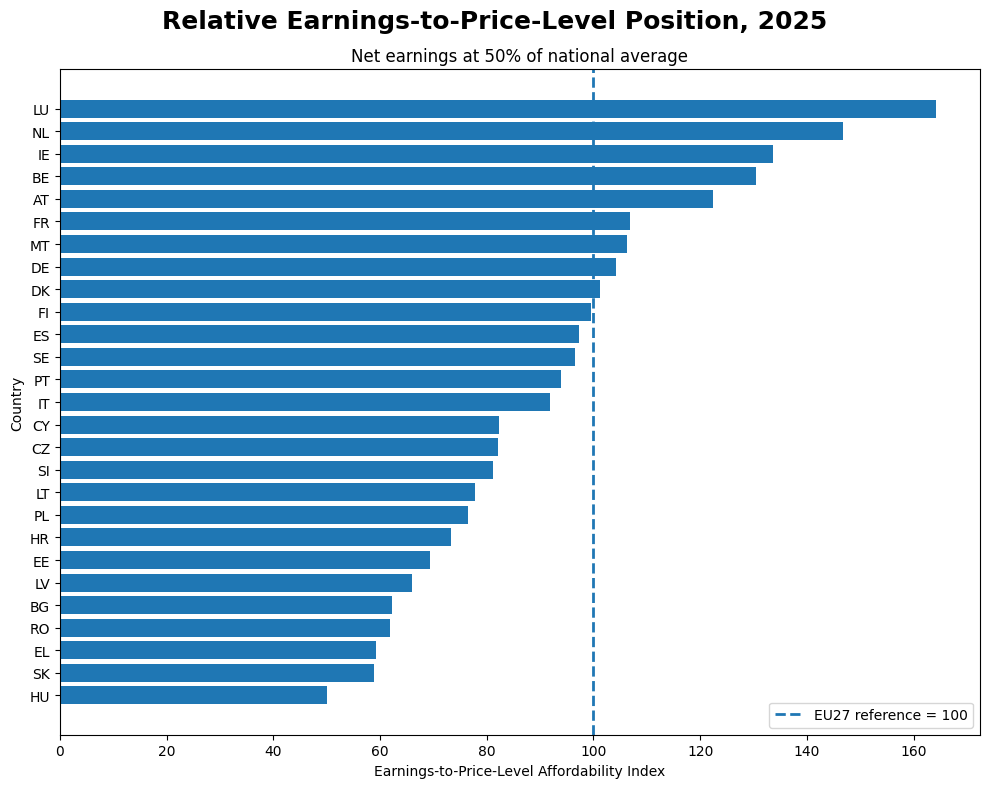

In [93]:
fig, ax = plt.subplots(figsize=(10, 8))

fig.suptitle(
    "Relative Earnings-to-Price-Level Position, 2025",
    fontsize=18,
    fontweight="bold"
)

ax.barh(
    df_affordability_50["geo"],
    df_affordability_50["affordability_index_50"]
)

ax.axvline(
    100,
    linestyle="--",
    linewidth=2,
    label="EU27 reference = 100"
)

ax.set_xlabel("Earnings-to-Price-Level Affordability Index")
ax.set_ylabel("Country")
ax.set_title(
    "Net earnings at 50% of national average"
)

ax.legend()

plt.tight_layout()
plt.show()

# Liniar Regression

In [94]:
slope_50, intercept_50 = np.polyfit(
    df_combined_50["pli"],
    df_combined_50["net_earnings_50_eur"],
    1
)

In [95]:
df_combined_50["predicted_earnings_50"] = (
    slope_50 * df_combined_50["pli"] + intercept_50
)

In [96]:
df_combined_50["earnings_residual_50"] = (
    df_combined_50["net_earnings_50_eur"]
    - df_combined_50["predicted_earnings_50"]
)

Pearson and R squared coefficients

In [97]:
correlation_50 = df_combined_50["pli"].corr(
    df_combined_50["net_earnings_50_eur"]
)

r_squared_50 = correlation_50 ** 2

print(correlation_50, r_squared_50)

0.9039914316589825 0.8172005085128569


# Merging the data

In [98]:
df_analysis_50 = df_combined_50[
    [
        "geo",
        "pli",
        "net_earnings_50_eur",
        "predicted_earnings_50",
        "earnings_residual_50",
        "earnings_to_pli_50",
        "affordability_index_50"
    ]
].copy()

In [99]:
df_comparison = df_combined.merge(
    df_analysis_50,
    on="geo",
    how="inner",
    suffixes=("_100", "_50")
)

In [100]:
df_comparison.columns

Index(['geo', 'Geopolitical entity (reporting)', 'pli_100', 'net_earnings_eur',
       'predicted_earnings', 'earnings_residual', 'earnings_index',
       'earnings_to_pli', 'affordability_index', 'pli_50',
       'net_earnings_50_eur', 'predicted_earnings_50', 'earnings_residual_50',
       'earnings_to_pli_50', 'affordability_index_50'],
      dtype='object')

In [101]:
(df_comparison["pli_100"] == df_comparison["pli_50"]).all()

np.True_

In [102]:
df_comparison = df_comparison.drop(columns=["pli_50"])

In [103]:
df_comparison = df_comparison.rename(
    columns={"pli_100": "pli"}
)

In [104]:
df_comparison["affordability_change"] = (
    df_comparison["affordability_index_50"]
    - df_comparison["affordability_index"]
)

In [105]:
df_comparison.info(

)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27 entries, 0 to 26
Data columns (total 15 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   geo                              27 non-null     object 
 1   Geopolitical entity (reporting)  27 non-null     object 
 2   pli                              27 non-null     float64
 3   net_earnings_eur                 27 non-null     float64
 4   predicted_earnings               27 non-null     float64
 5   earnings_residual                27 non-null     float64
 6   earnings_index                   27 non-null     float64
 7   earnings_to_pli                  27 non-null     float64
 8   affordability_index              27 non-null     float64
 9   net_earnings_50_eur              27 non-null     float64
 10  predicted_earnings_50            27 non-null     float64
 11  earnings_residual_50             27 non-null     float64
 12  earnings_to_pli_50      

In [106]:
df_comparison[
    [
        "geo",
        "affordability_index",
        "affordability_index_50",
        "affordability_index",
        "affordability_change"
    ]
].sort_values(
    "affordability_change",
    ascending=False
)

,geo,affordability_index,affordability_index_50,affordability_index,affordability_change
20,NL,115.120647,146.756155,115.120647,31.635508
1,BE,110.708470,130.438403,110.708470,19.729934
14,IE,120.683234,133.623184,120.683234,12.939950
17,LU,153.226448,164.224543,153.226448,10.998095
22,PT,84.512082,93.968939,84.512082,9.456857
11,FR,103.800826,106.920583,103.800826,3.119757
19,MT,103.217373,106.243108,103.217373,3.025735
0,AT,120.927437,122.340706,120.927437,1.413269
4,CZ,81.283809,82.127727,81.283809,0.843918
15,IT,93.587433,91.844818,93.587433,-1.742615


# Plot

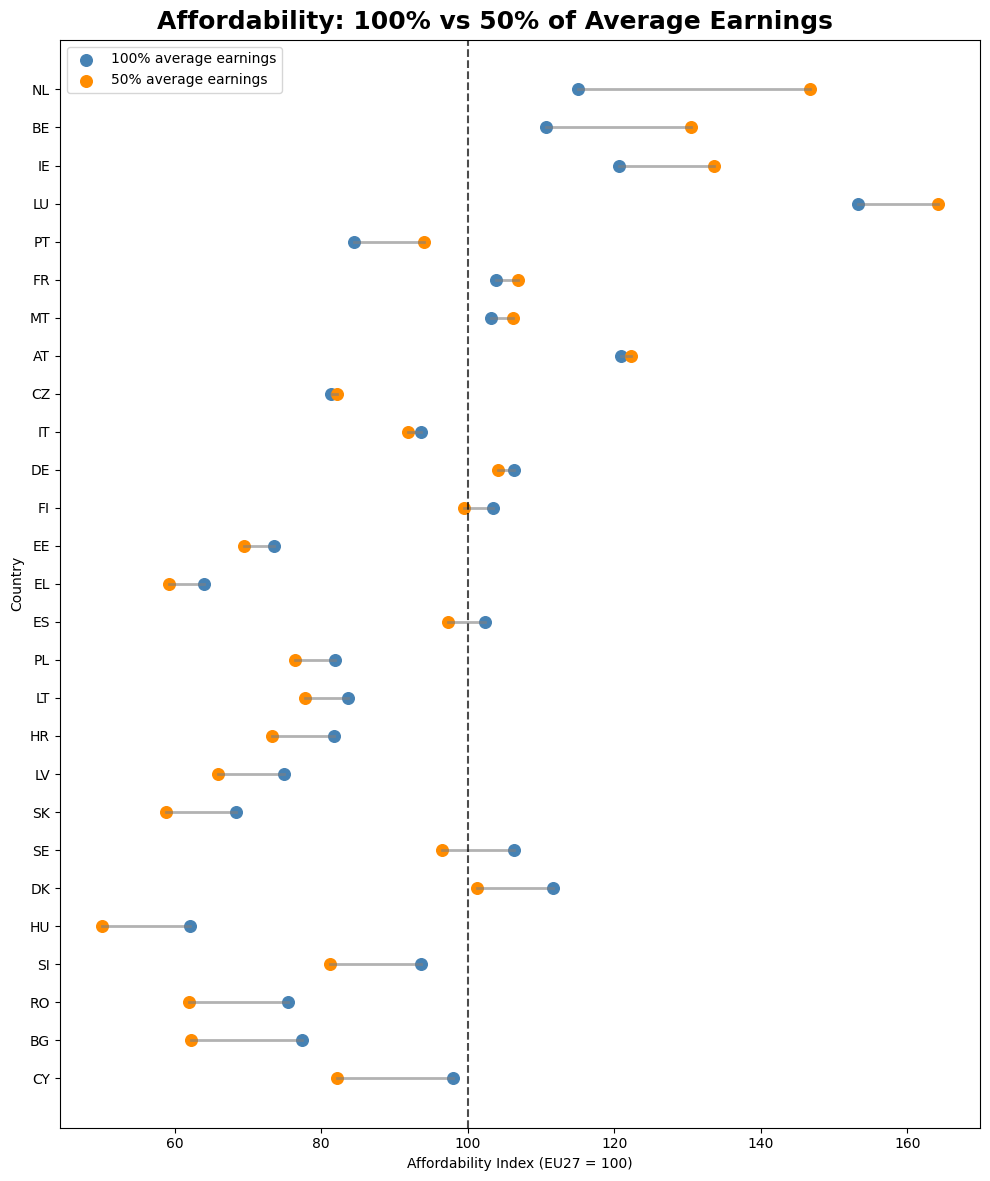

In [107]:
df_plot = df_comparison.sort_values(
    "affordability_change"
).copy()

fig, ax = plt.subplots(figsize=(10, 12))

fig.suptitle(
    "Affordability: 100% vs 50% of Average Earnings",
    fontsize=18,
    fontweight="bold"
)

y = range(len(df_plot))

for i, (_, row) in enumerate(df_plot.iterrows()):

    # Connection
    ax.plot(
        [row["affordability_index"], row["affordability_index_50"]],
        [i, i],
        color="gray",
        linewidth=2,
        alpha=0.6
    )

    # 100% earner
    ax.scatter(
        row["affordability_index"],
        i,
        color="steelblue",
        s=70,
        label="100% average earnings" if i == 0 else ""
    )

    # 50% earner
    ax.scatter(
        row["affordability_index_50"],
        i,
        color="darkorange",
        s=70,
        label="50% average earnings" if i == 0 else ""
    )

ax.set_yticks(list(y))
ax.set_yticklabels(df_plot["geo"])

# EU27 benchmark
ax.axvline(
    100,
    color="black",
    linestyle="--",
    linewidth=1.5,
    alpha=0.7
)

ax.set_xlabel("Affordability Index (EU27 = 100)")
ax.set_ylabel("Country")


ax.legend()

plt.tight_layout()
plt.show()

In [108]:
# Export processed data
processed_path = Path("../data/processed")
processed_path.mkdir(exist_ok=True)

df_comparison.to_csv(
    processed_path / "eu27_earnings_affordability_final.csv",
    index=False
)

In [109]:
df_comparison.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27 entries, 0 to 26
Data columns (total 15 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   geo                              27 non-null     object 
 1   Geopolitical entity (reporting)  27 non-null     object 
 2   pli                              27 non-null     float64
 3   net_earnings_eur                 27 non-null     float64
 4   predicted_earnings               27 non-null     float64
 5   earnings_residual                27 non-null     float64
 6   earnings_index                   27 non-null     float64
 7   earnings_to_pli                  27 non-null     float64
 8   affordability_index              27 non-null     float64
 9   net_earnings_50_eur              27 non-null     float64
 10  predicted_earnings_50            27 non-null     float64
 11  earnings_residual_50             27 non-null     float64
 12  earnings_to_pli_50      

In [110]:
print(processed_path / "eu27_earnings_affordability_final.csv")

..\data\processed\eu27_earnings_affordability_final.csv


In [111]:
for path in sorted(Path(".").rglob("*")):
    if path.is_file() and ".venv" not in path.parts and ".git" not in path.parts:
        print(path)

cost_of_living_analysis.ipynb
